# Práctica 8: Pronóstico (Forecasting - Series de Tiempo)

**Objetivo:** Crear un modelo de regresión lineal para predecir la evolución temporal de una métrica clave (Expected Goals - xG) en la Premier League 2024-2025.

### Metodología:
1. **Agregación Temporal:** Convertir los datos de disparos individuales en una serie diaria de xG total.
2. **Análisis de Tendencia:** Visualizar cómo ha cambiado la peligrosidad de los partidos a lo largo del tiempo.
3. **Modelado:** Utilizar Regresión Lineal para proyectar la tendencia hacia el futuro.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from datetime import datetime

# Cargar datos
df = pd.read_csv('cleaned_epl_shots.csv')

# Convertir fecha a objeto datetime
df['match_date'] = pd.to_datetime(df['match_date'])

print(f"Rango de fechas: {df['match_date'].min()} a {df['match_date'].max()}")

Rango de fechas: 2024-08-17 00:00:00 a 2025-05-25 00:00:00


## 1. Preparación de la Serie de Tiempo

Agruparemos el `xg` total generado en cada fecha de la liga.

In [2]:
# Agrupar xG por fecha
daily_xg = df.groupby('match_date')['xg'].sum().reset_index()
daily_xg = daily_xg.sort_values('match_date')

# Crear un índice numérico para el tiempo (días transcurridos desde el inicio)
daily_xg['days_since_start'] = (daily_xg['match_date'] - daily_xg['match_date'].min()).dt.days

print(daily_xg.head())

  match_date         xg  days_since_start
0 2024-08-17   4.485324                 0
1 2024-08-18   4.751747                 1
2 2024-08-19   2.221350                 2
3 2024-08-24  20.445823                 7
4 2024-08-25   3.949872                 8


## 2. Visualización de la Serie de Tiempo

Graficamos el xG diario para observar la variabilidad y posibles tendencias.

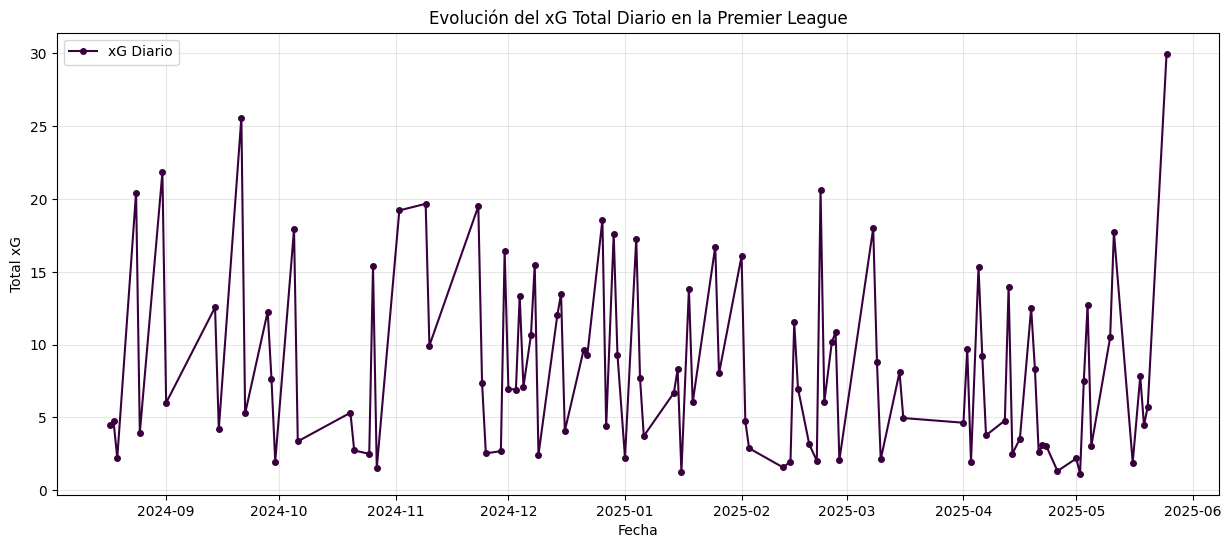

In [3]:
plt.figure(figsize=(15,6))
plt.plot(daily_xg['match_date'], daily_xg['xg'], label='xG Diario', color='#38003c', marker='o', markersize=4)
plt.title('Evolución del xG Total Diario en la Premier League')
plt.xlabel('Fecha')
plt.ylabel('Total xG')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 3. Entrenamiento del Modelo de Regresión

Modelaremos el xG diario en función del tiempo transcurrido.

In [4]:
# Definir variables
X = daily_xg[['days_since_start']].values
y = daily_xg['xg'].values

# Crear y entrenar el modelo
model = LinearRegression()
model.fit(X, y)

# Realizar predicciones sobre los datos existentes
y_pred = model.predict(X)

print(f"Coeficiente (Tendencia): {model.coef_[0]:.4f}")
print(f"Puntaje R2: {r2_score(y, y_pred):.4f}")

Coeficiente (Tendencia): -0.0100
Puntaje R2: 0.0162


## 4. Pronóstico a Futuro

Predeciremos el xG acumulado para los próximos 30 días.

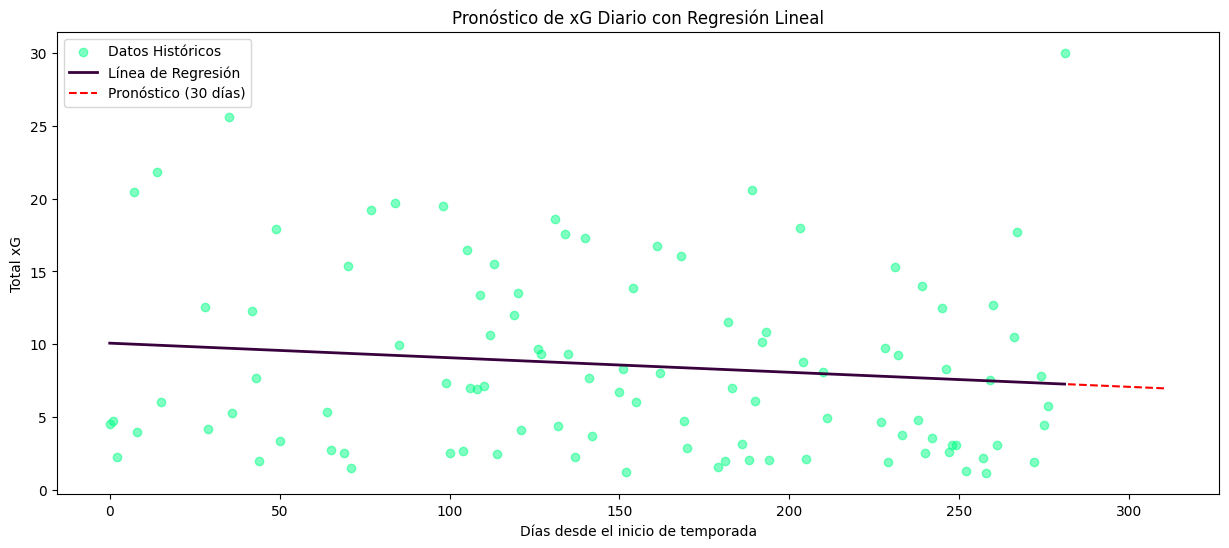

In [5]:
# Crear fechas futuras
last_day = daily_xg['days_since_start'].max()
future_days = np.array(range(last_day + 1, last_day + 31)).reshape(-1, 1)

# Predecir
future_pred = model.predict(future_days)

# Visualizar resultados
plt.figure(figsize=(15,6))
plt.scatter(X, y, color='#00ff85', alpha=0.5, label='Datos Históricos')
plt.plot(X, y_pred, color='#38003c', linewidth=2, label='Línea de Regresión')
plt.plot(future_days, future_pred, color='red', linestyle='--', label='Pronóstico (30 días)')

plt.title('Pronóstico de xG Diario con Regresión Lineal')
plt.xlabel('Días desde el inicio de temporada')
plt.ylabel('Total xG')
plt.legend()
plt.show()

## 5. Análisis Profundo de Resultados

Basado en las métricas obtenidas por el modelo, podemos extraer las siguientes conclusiones sobre la Premier League 2024-2025:

### A. La Tendencia de Peligrosidad (Coeficiente: -0.0100)
*   **Significado:** Por cada día que transcurre en la temporada, el total de xG diario de la liga disminuye, en promedio, **0.01 unidades**.
*   **Interpretación Deportiva:** Existe una ligera tendencia hacia el **orden defensivo**. Conforme avanza la liga, los equipos suelen ajustar sus sistemas defensivos, se vuelven más cautelosos para asegurar puntos o sufren fatiga acumulada, lo que reduce sutilmente la calidad de las oportunidades de gol creadas.

### B. Capacidad Predictiva (Puntaje R2: 0.0162)
*   **Significado:** El tiempo (días transcurridos) solo explica el **1.62%** de la variación del xG diario.
*   **¿Por qué es bajo?:** La Premier League tiene una alta **varianza por calendario**. Los fines de semana concentran muchos partidos (picos de xG de ~20), mientras que los lunes o martes suelen tener pocos o ninguno (caídas a ~0). 
*   **Conclusión:** El modelo confirma que la generación de peligro es un fenómeno **estocástico e irregular** que depende más del volumen de partidos del día que del momento de la temporada.

### C. Visualización del Pronóstico
*   **Picos de Voltaje:** Los puntos en el scatter plot muestran la realidad caótica del fútbol profesional.
*   **Línea de Regresión:** Sirve como una "línea de base" de rendimiento. Cualquier día que se sitúe significativamente por encima de esta línea puede considerarse una jornada de espectáculo ofensivo atípico.
*   **Proyección a 30 días:** El modelo proyecta una continuación de la pendiente negativa, sugiriendo que el juego seguirá cerrándose ligeramente en el próximo mes.

### D. Limitaciones y Próximos Pasos
1. **No Linealidad:** El fútbol no es lineal; eventos como el mercado de fichajes de invierno o las rachas de lesiones pueden alterar la tendencia bruscamente.
2. **Estacionalidad:** Para mejorar el R2, se debería incluir una variable booleana que indique si el día es "Fin de Semana" o "Entre Semana".